* select a dataset based on sustainability or green skill and perform K Means Clustering.
* ⁠you might need to clean the data, analyze it using seaborn and perform the algorithm and check its evaluation.
* ⁠decide your group members between 3-5 and decide a project title by today and submit that in a notepad in your github

In [4]:
import pandas as p
data = p.read_csv('Garbage_Detection.csv')
print('The dataset is:')
print(data.info())
print('Description:')
print(data.describe())
data = data.drop_duplicates()

The dataset is:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Image_ID      20 non-null     object 
 1   Location      20 non-null     object 
 2   Lighting      19 non-null     object 
 3   Weather       20 non-null     object 
 4   Object_Size   20 non-null     object 
 5   Waste_Type    19 non-null     object 
 6   Confidence    19 non-null     float64
 7   Distance_m    18 non-null     float64
 8   Camera_Angle  19 non-null     object 
 9   Detected      19 non-null     object 
dtypes: float64(2), object(8)
memory usage: 1.7+ KB
None
Description:
       Confidence  Distance_m
count   19.000000   18.000000
mean     0.776316    3.994444
std      0.151372    2.013622
min      0.550000    1.500000
25%      0.625000    2.225000
50%      0.820000    3.300000
75%      0.905000    5.700000
max      0.980000    7.200000


In [17]:
print('The number of null values in dataset are:')
print(data.isnull().sum())
if data.isnull().sum().any():
    for i in data.columns:
        if data[i].dtype=='object':
            data[i] = data[i].fillna(data[i].mode()[0])
        else:
            data[i] = data[i].fillna(data[i].mean())

The number of null values in dataset are:
Image_ID        0
Location        0
Lighting        0
Weather         0
Object_Size     0
Waste_Type      0
Confidence      0
Distance_m      0
Camera_Angle    0
Detected        0
dtype: int64


Using Seaborn library:
Countplot:


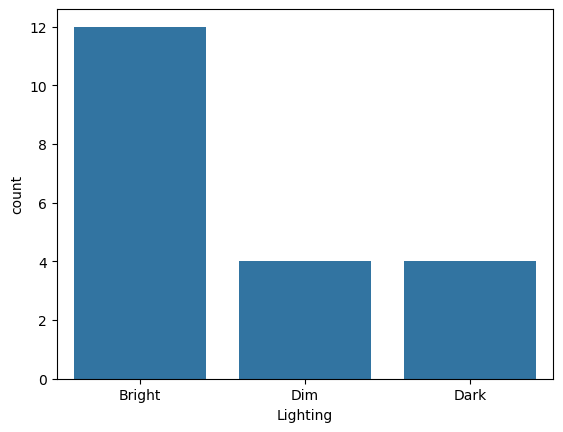

In [13]:
import seaborn as s
import matplotlib.pyplot as plt
print('Using Seaborn library:')
print('Countplot:')
s.countplot(x='Lighting',data=data)
plt.show()

Histogram


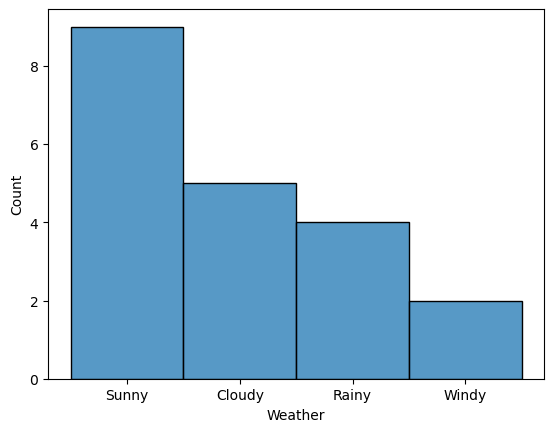

In [19]:
print('Histogram')
s.histplot(data['Weather'])
plt.show()

Boxplot:


<Axes: xlabel='Distance_m'>

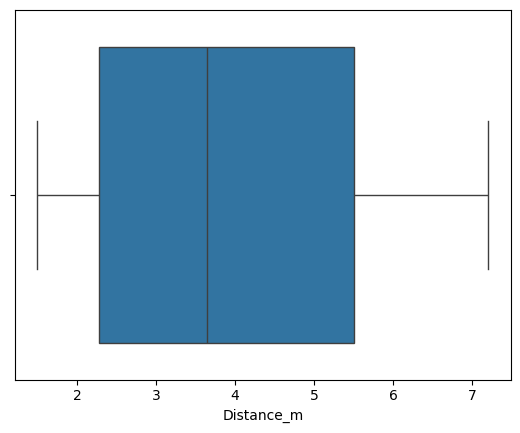

In [22]:
print('Boxplot:')
s.boxplot(x='Distance_m',data=data)

In [21]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
l = LabelEncoder()
data['Image_ID'] = l.fit_transform(data['Image_ID'])
data['Location'] = l.fit_transform(data['Location'])
data['Lighting'] = l.fit_transform(data['Lighting'])
data['Weather'] = l.fit_transform(data['Weather'])
data['Object_Size'] = l.fit_transform(data['Object_Size'])
data['Waste_Type'] = l.fit_transform(data['Waste_Type'])
data['Camera_Angle'] = l.fit_transform(data['Camera_Angle'])
data['Detected'] = l.fit_transform(data['Detected'])
print('After LabelEncoding:')
print(data)

After LabelEncoding:
    Image_ID  Location  Lighting  Weather  Object_Size  Waste_Type  \
0          0         2         0        2            0           4   
1          1         3         2        0            1           3   
2          2         0         0        2            2           1   
3          3         5         1        1            1           4   
4          4         2         0        2            0           2   
5          5         1         0        0            2           0   
6          6         4         2        2            1           4   
7          7         3         0        2            0           3   
8          8         0         0        3            2           2   
9          9         5         1        1            1           0   
10        10         2         0        2            0           4   
11        11         1         2        0            2           4   
12        12         4         0        2            1           3   

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
x = data.drop('Location',axis=1)
y = data['Location']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=50)
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print('Prediction:')
print(y_pred)

Prediction:
[1 0 1 1 4 1]


C:\Users\DIVYA\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
import sklrearn.metrics as m

In [43]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=5,random_state=82)
clusters = km.fit_predict(x)

C:\Users\DIVYA\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
